In [102]:
from pyfiles.preamble import *
enable_autoreload()

!{sys.executable} -m pip install ET-eds-api --upgrade --quiet

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Fetching EnergyPLAN input data

This notebook produces the EnergyPLAN distribution files (`.txt`) for electricity demand, solar, offshore wind, onshore wind, and spot price. 

All data is sourced from Energistyrelsen (EDS) via `build_vp`. A custom nuclear dispatch timeseries is also constructed at the end.

Specifically, I use the python client for EDS, `ET-eds-api`, developed as part of this project. Read about it [here](https://github.com/cfn368/ET-eds-api).

### 1.1 Time frame

*Set the calculation period and derive helper variables used in all subsequent API calls.*

In [103]:
start = 2024
end   = 2025

results = VE_run(
    specs = [
        dict(
            value_columns = ["SolarPowerLt10kW_MWh", "SolarPowerGe10Lt40kW_MWh", "SolarPowerGe40kW_MWh"],
            cap_column    = ["SolarPowerCapacity"],
            col_name      = "PV_VE",
        ),
        dict(
            value_columns = ["OffshoreWindLt100MW_MWh", "OffshoreWindGe100MW_MWh"],
            cap_column    = ["OffshoreWindCapacity"],
            col_name      = "WS_VE",
        ),
        dict(
            value_columns = ["OnshoreWindLt50kW_MWh", "OnshoreWindGe50kW_MWh"],
            cap_column    = ["OnshoreWindCapacity"],
            col_name      = "WL_VE",
        ),
    ],
    start    = start,
    end      = end,
    include_wp = True,
    cache    = True,
    save_txt = True,
    EP_style = True
)


Index denominator [PV_VE]: ===================
  SolarPowerCapacity: 3913.23882  (last observed)
Saved 8784-row txt: variation_patterns\PV_VE_2024_2025.txt

Index denominator [WS_VE]: ===================
  OffshoreWindCapacity: 2645.5  (last observed)
Saved 8784-row txt: variation_patterns\WS_VE_2024_2025.txt

Index denominator [WL_VE]: ===================
  OnshoreWindCapacity: 4861.831  (last observed)
Saved 8784-row txt: variation_patterns\WL_VE_2024_2025.txt


c:\Users\LinusLindquist\anaconda3\Lib\site-packages\ET_eds_api\fetcher_ve.py:253: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  p_combined = pd.concat([


Saved 8784-row txt: variation_patterns\wp_2024_2025.txt


In [104]:
PV   = results["PV_VE"]
WS   = results["WS_VE"]
WL   = results["WL_VE"]
wp_h = results["wp_h"]
q_h  = results["q_h"]
year_label = f"{start}–{end}"

*save to the right place*

In [105]:
src = Path("variation_patterns")
dst = Path("..") / "ZipEnergyPLAN163" / "energyPlan Data" / "Distributions"

for f in src.glob("*.txt"):
    shutil.copy2(f, dst / f.name)

### 1.2. Sanity checks

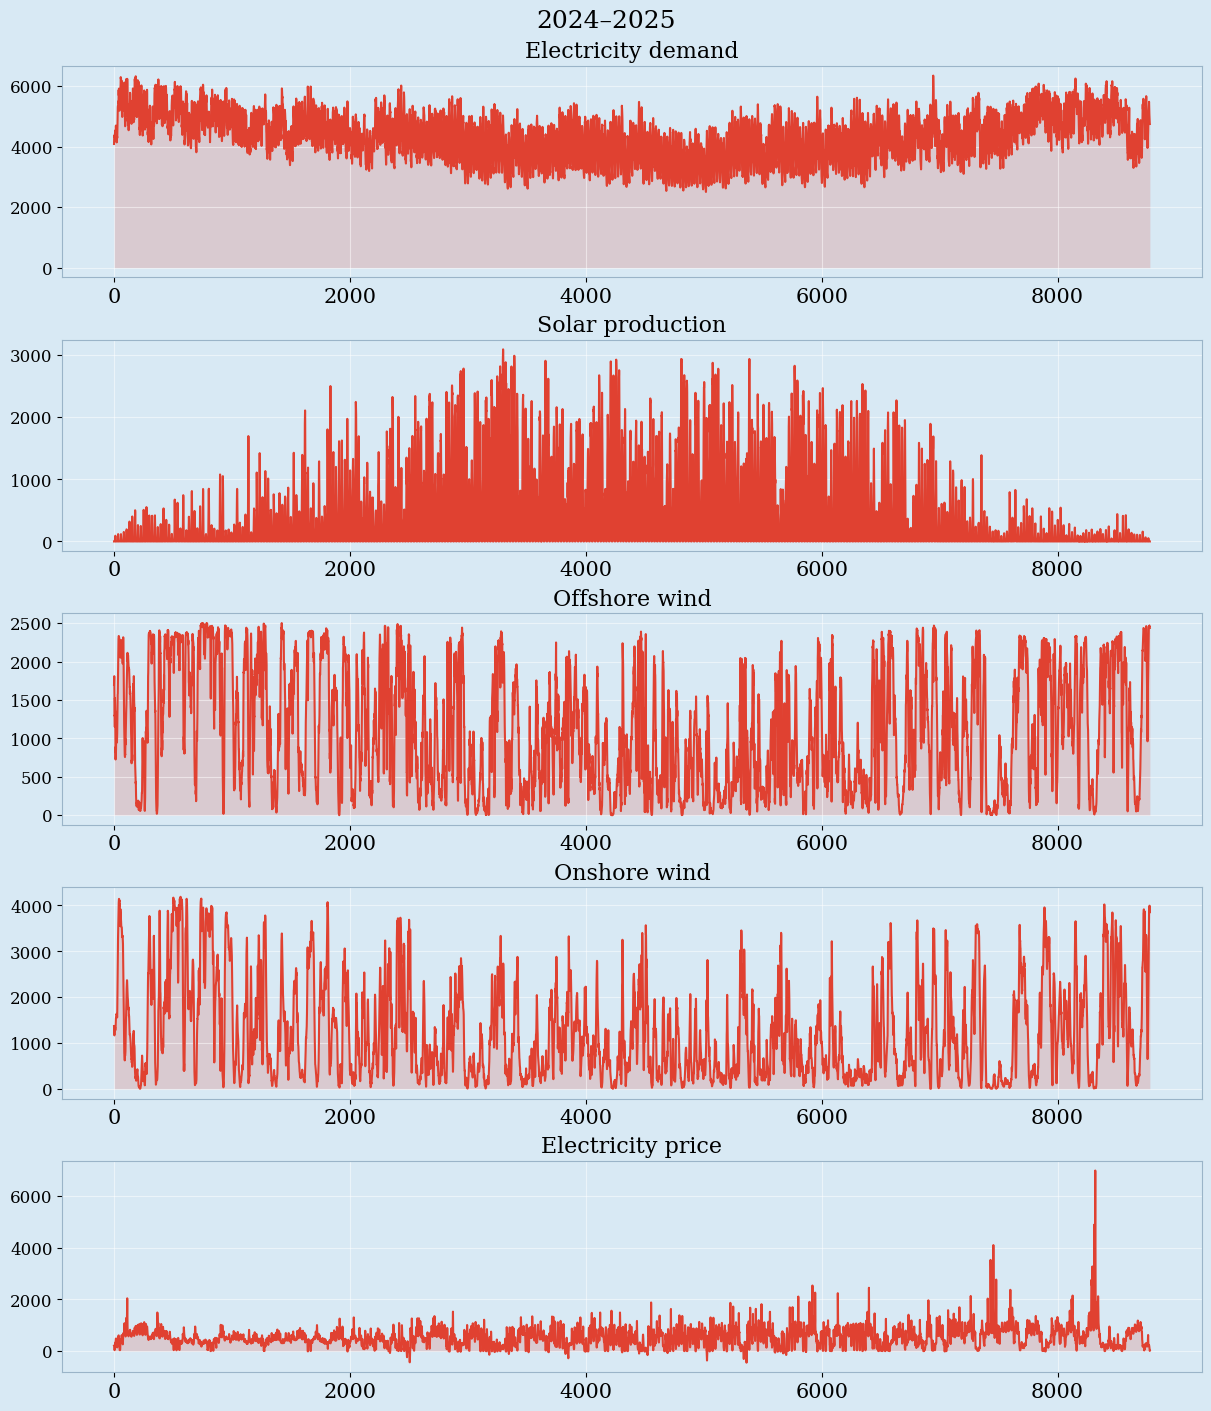

In [106]:
labels = [
    "Electricity demand",
    "Solar production",
    "Offshore wind",
    "Onshore wind",
    "Electricity price",
]

series_list = [
    q_h.GrossConsumptionMWh.rename(labels[0]), 
    PV.PV_VE.rename(labels[1]), 
    WS.WS_VE.rename(labels[2]),
    WL.WL_VE.rename(labels[3]), 
    wp_h.SpotPriceDKK_weighted.rename(labels[4])
]

bg_color   = "#d8e9f4"
fill_alpha = 0.18

fig, axes = plt.subplots(5, 1, figsize=(12, 14), constrained_layout=True)
fig.patch.set_facecolor(bg_color)
for ax, s in zip(axes, series_list):
    x, y = np.arange(len(s)), s.to_numpy()
    ax.fill_between(x, 0, y, alpha=fill_alpha, color="#E04131", linewidth=0)
    ax.plot(x, y, color="#E04131")
    ax.set_title(s.name)
    ax.set_facecolor(bg_color)
    for spine in ax.spines.values():
        spine.set_edgecolor("#9ab4c8")
    ax.grid(True, which="major", linestyle="-", color="white", alpha=0.5)

fig.suptitle(f"{year_label}")
plt.show()

*indexes*

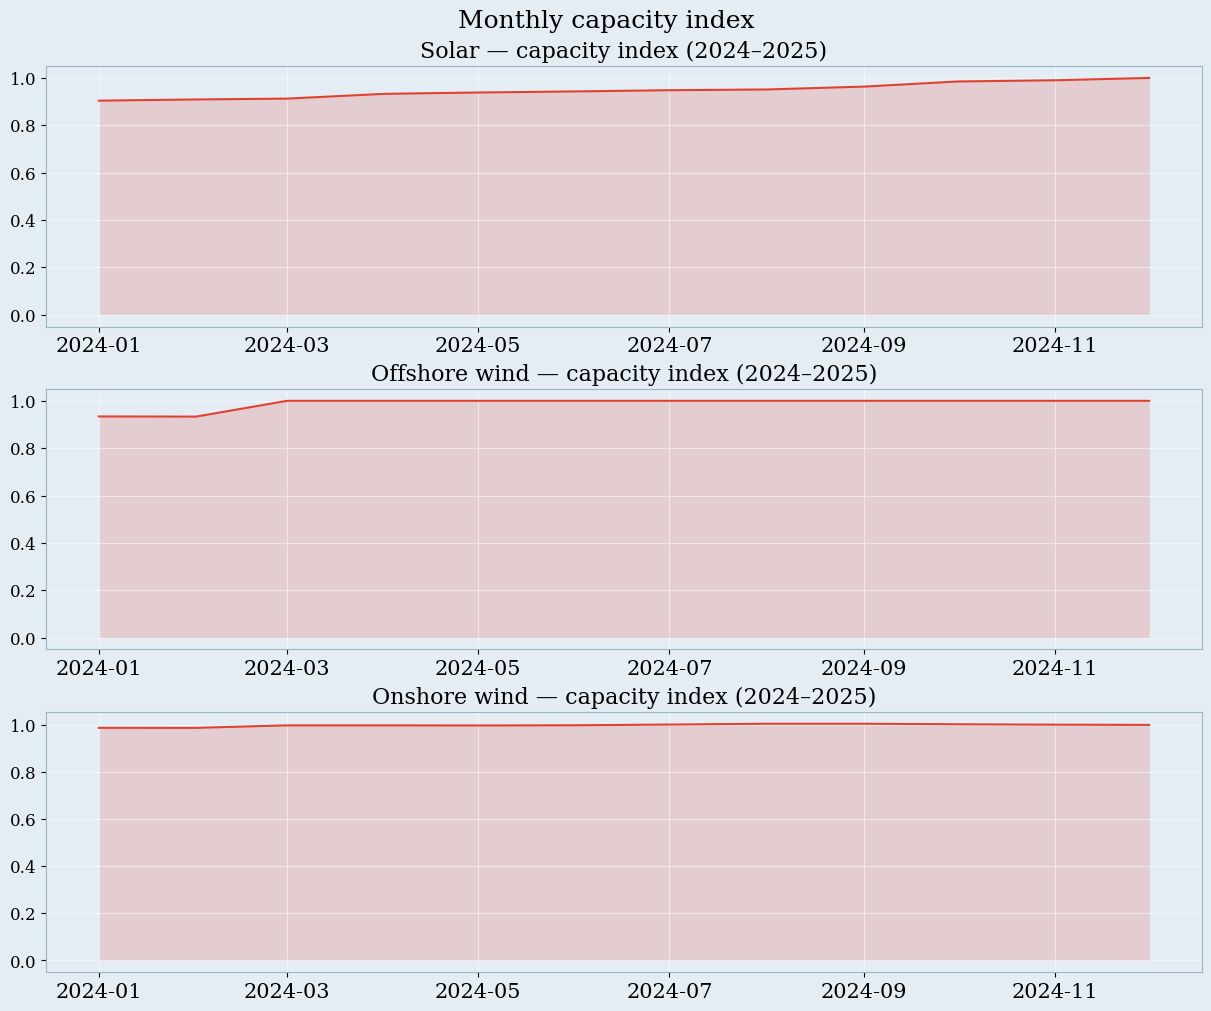

In [107]:
bg_color   = "#e4edf3"
fill_alpha = 0.18

fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)
fig.patch.set_facecolor(bg_color)

for ax, df, idx_col, title in zip(axes,
                                   [PV, WS, WL],
                                   ["PV_VE_idx", "WS_VE_idx", "WL_VE_idx"],
                                   ["Solar", "Offshore wind", "Onshore wind"]):
    monthly = df.drop_duplicates("month")
    x, y = monthly.month, monthly[idx_col]
    ax.fill_between(x, 0, y, alpha=fill_alpha, color="#E04131", linewidth=0)
    ax.plot(x, y, color="#E04131")
    ax.set_title(f"{title} — capacity index ({year_label})")
    ax.set_facecolor(bg_color)
    for spine in ax.spines.values():
        spine.set_edgecolor("#9ab4c8")
    ax.grid(True, which="major", linestyle="-", color="white", alpha=0.5)

fig.suptitle("Monthly capacity index")
plt.show()

## 2. Custom timeseries

*`year-round nuclear heat dispatch`*

Year-round variant: heat is proportional to DH demand at all hours — no above-mean threshold. The electricity fraction is

$$
    A_h = 1 - f \cdot \frac{d_h}{\max_h(d_h)}
$$

All hours produce some heat; the CSHP distribution normalises to mean $= 1$ over all 8784 hours. Active value: $f = 0.70$.

In [110]:
INPUT_DIR = Path("..") / "ZipEnergyPLAN163" / "energyPlan Data" / "Distributions"
dh        = np.loadtxt(INPUT_DIR / 'DK-distr-heat.txt', dtype=str)
dh        = np.char.replace(dh, ',', '.').astype(float)

# 3. year-round nuclear heat dispatch  (f=0.40 active)
F_VALUES_YEAR = [0.3, 0.50]
F_ACTIVE_YEAR = 0.3   # must match create_scenario.py

for f in F_VALUES_YEAR:
    A    = 1 - f * dh / dh.max()
    heat = 1 - A                   # = f * dh / dh.max()
    cshp = heat / heat.mean()      # all hours non-zero, normalise to mean=1

    txt_el = "\n".join(f"{v:.6f}".replace(".", ",") for v in A) + "\n"
    txt_cs = "\n".join(f"{v:.6f}".replace(".", ",") for v in cshp) + "\n"

    pct = int(round(f * 100))
    (INPUT_DIR / f'nuclear_dh_year_f{pct:02d}.txt').write_text(txt_el, encoding='utf-8')
    (INPUT_DIR / f'cshp_dh_year_f{pct:02d}.txt').write_text(txt_cs, encoding='utf-8')

    annual_heat = heat.sum() * 1000 * 2.5 / 1e6
    active_tag  = '  ← active' if f == F_ACTIVE_YEAR else ''
    print(f"f={f:.2f}  peak A={A.min():.2f}  heat={annual_heat:.2f} TWh  "
          f"hrs={len(dh)}{active_tag}")
    if f == F_ACTIVE_YEAR:
        print(f"  → input_cshp_th_gr3 = {annual_heat:.4f}")

f=0.30  peak A=0.70  heat=2.34 TWh  hrs=8784  ← active
  → input_cshp_th_gr3 = 2.3443
f=0.50  peak A=0.50  heat=3.91 TWh  hrs=8784


*`3. visual comparison of dispatch profiles`*

*Weekly mean heat diversion $(1 - A_h)$ for the constant 5 % profile and each demand-weighted $f$, overlaid on the normalised DH demand profile.*

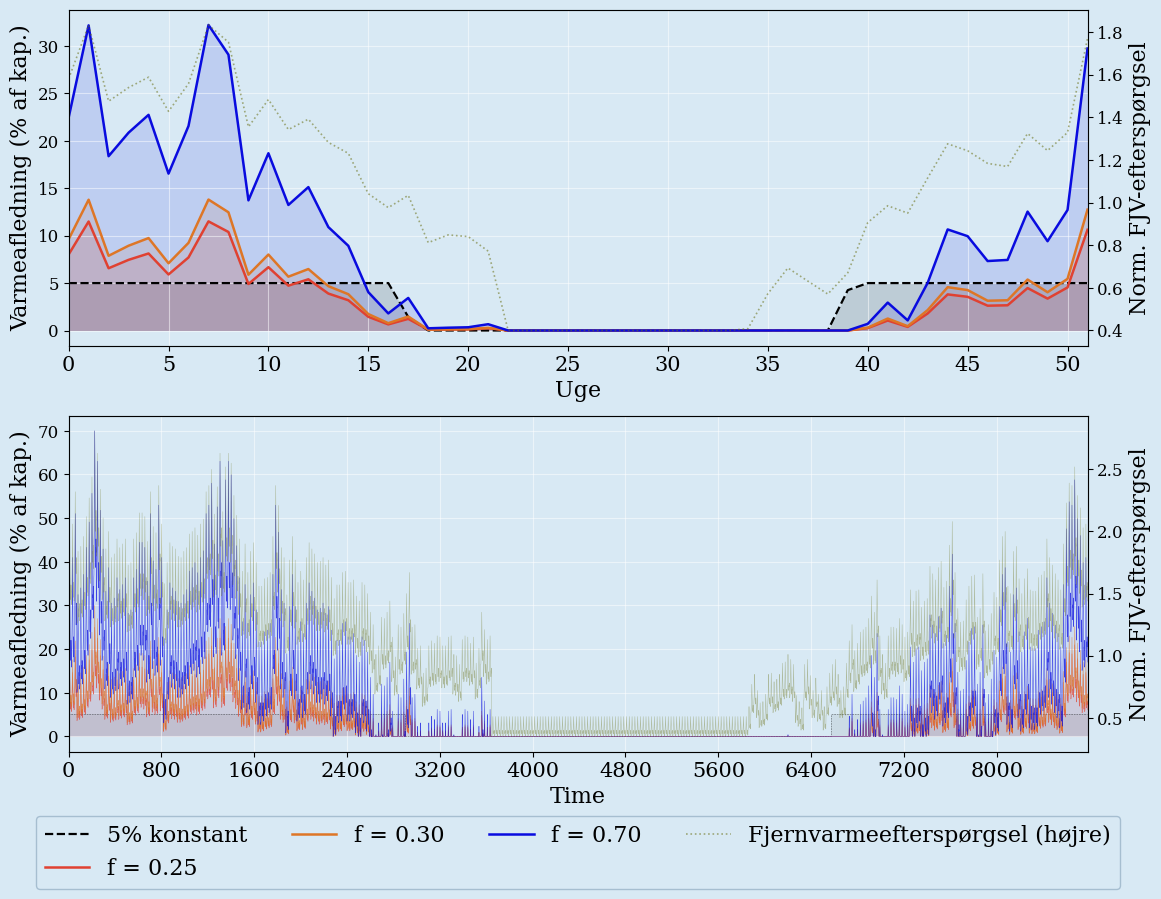

In [111]:
# 3. visual comparison of dispatch profiles — weekly and hourly
F_PLOT  = [0.25, 0.30, 0.70]
WEEK    = 168
N       = len(dh)
N_WEEKS = N // WEEK
wk      = np.arange(N_WEEKS)
hr      = np.arange(N)

def _load(fname):
    a = np.loadtxt(INPUT_DIR / fname, dtype=str)
    return np.char.replace(a, ',', '.').astype(float)[:N]

const5 = _load('5_pct_dh.txt')

profiles = {'5% konstant': (1 - const5, "#000000", '--', 1.6)}
colors   = ['#E04131', '#DE7626', '#090BDF']
for f, col in zip(F_PLOT, colors):
    A_f = 1 - f * dh_excess / dh_excess.max()
    profiles[f'f = {f:.2f}'] = (1 - A_f, col, '-', 1.8)

def _weekly(v):
    return v[:N_WEEKS * WEEK].reshape(N_WEEKS, WEEK).mean(axis=1)

bg_color   = "#d8e9f4"
fill_alpha = 0.12

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 9))
fig.patch.set_facecolor(bg_color)

# — panel 1: weekly means —
ax2 = ax1.twinx()
for label, (heat, col, ls, lw) in profiles.items():
    y = _weekly(heat) * 100
    ax1.fill_between(wk, 0, y, alpha=fill_alpha, color=col, linewidth=0)
    ax1.plot(wk, y, label=label, color=col, ls=ls, lw=lw)
ax2.plot(wk, _weekly(dh), color='#6A7015', lw=1.2, ls=':', alpha=0.55,
         label='Fjernvarmeefterspørgsel (højre)')
ax1.set_xlabel('Uge')
ax1.set_ylabel('Varmeafledning (% af kap.)')
ax2.set_ylabel('Norm. FJV-efterspørgsel')
ax1.set_facecolor(bg_color)
for spine in ax1.spines.values():
    spine.set_edgecolor("#9ab4c8")
ax1.grid(True, which="major", linestyle="-", color="white", alpha=0.5)
ax1.set_xlim(wk.min(), wk.max())
ax1.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()

# — panel 2: hourly —
ax4 = ax3.twinx()
for label, (heat, col, ls, lw) in profiles.items():
    y = heat * 100
    ax3.fill_between(hr, 0, y, alpha=fill_alpha * 0.5, color=col, linewidth=0)
    ax3.plot(hr, y, color=col, ls=ls, lw=0.35, alpha=0.75)
ax4.plot(hr, dh, color='#6A7015', lw=0.35, ls='-', alpha=0.4)
ax3.set_xlabel('Time')
ax3.set_ylabel('Varmeafledning (% af kap.)')
ax4.set_ylabel('Norm. FJV-efterspørgsel')
ax3.set_facecolor(bg_color)
for spine in ax3.spines.values():
    spine.set_edgecolor("#9ab4c8")
ax3.grid(True, which="major", linestyle="-", color="white", alpha=0.5)
ax3.set_xlim(hr.min(), hr.max())
ax3.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
ax3.legend(lines1 + lines2, labs1 + labs2, loc='center', frameon=True,
           bbox_to_anchor=(0.5, -0.3), ncols=4,
           facecolor=bg_color, edgecolor="#9ab4c8")

plt.tight_layout()
plt.show()